# Introduction

This notebook walks throught the production of Fig. 06, which plots percentage differences in Stokes drift magnitude between the WW3-VLWD model and the WW3-NOXYZ models, where XYZ stands for a model with a specific CEW mechanism disabled, for a representative model snapshot.

## Imports

In [34]:
import sys
sys.path.append("../src")

In [35]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from map_plot import (
    subset,
    add_arrow_to_axis,
    add_box_to_axis,
    make_four_panel_money_figure,
)

plt.rcdefaults()
plt.style.use("../src/paper.mplstyle")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

We use the raw WAVEWATCH III (WW3) output to plot these maps.

In [36]:
data_path = Path('../data/raw_ww3/')

The currents are the same in the LVWD&CUR and HVWD&CUR configurations, so we only open the former.

In [37]:
ww3_lvwd_cur = xr.open_dataset(data_path / 'lvwd_cur.nc')

ww3_noref = xr.open_dataset(data_path / 'noref.nc')
ww3_nocrt = xr.open_dataset(data_path / 'nocrt.nc')
ww3_norel = xr.open_dataset(data_path / 'norel.nc')
ww3_noadv = xr.open_dataset(data_path / 'noadv.nc')

November 30, 2020 at 16:00 UTC was found to demonstrate wind- and current-driven variability in the Stokes drift very effectively. The spatial extent is nearly as large as the model domain, but is square, which is better for plotting.

In [38]:
timestep = '2020-11-30T16:00:00.000000000'

lons = slice(None, 240)
lats = slice(25, 45)

In [39]:
ww3_lvwd_cur_plt = subset(ww3_lvwd_cur, timestep, lons, lats)

ww3_noref_plt = subset(ww3_noref, timestep, lons, lats)
ww3_nocrt_plt = subset(ww3_nocrt, timestep, lons, lats)
ww3_norel_plt = subset(ww3_norel, timestep, lons, lats)
ww3_noadv_plt = subset(ww3_noadv, timestep, lons, lats)

We close the datasets we are not using anymore.

In [40]:
ww3_lvwd_cur.close(); del ww3_lvwd_cur

ww3_noref.close(); del ww3_noref
ww3_nocrt.close(); del ww3_nocrt
ww3_norel.close(); del ww3_norel
ww3_noadv.close(); del ww3_noadv

# Variables to Plot

We compute and extract the relevant variables for Fig. 01.

In [41]:
us_lvwd_cur_plt = np.hypot(ww3_lvwd_cur_plt.uuss, ww3_lvwd_cur_plt.vuss)

us_noref_plt = np.hypot(ww3_noref_plt.uuss, ww3_noref_plt.vuss)
us_nocrt_plt = np.hypot(ww3_nocrt_plt.uuss, ww3_nocrt_plt.vuss)
us_norel_plt = np.hypot(ww3_norel_plt.uuss, ww3_norel_plt.vuss)
us_noadv_plt = np.hypot(ww3_noadv_plt.uuss, ww3_noadv_plt.vuss)

Percent reduction relative to the baseline is computed as

$$
\%\,\mathrm{reduction}
=
\frac{\mathrm{baseline} - \mathrm{perturbation}}
{\mathrm{baseline}}
\times 100,
$$

where the baseline includes all processes and the perturbation has one process turned off.

In [42]:
def pct_reduction(baseline, perturbation):
    return ((baseline - perturbation) / baseline) * 100

In [43]:
us_noref_plt_diff = pct_reduction(us_lvwd_cur_plt, us_noref_plt)
us_nocrt_plt_diff = pct_reduction(us_lvwd_cur_plt, us_nocrt_plt)
us_norel_plt_diff = pct_reduction(us_lvwd_cur_plt, us_norel_plt)
us_noadv_plt_diff = pct_reduction(us_lvwd_cur_plt, us_noadv_plt)

# Plotting

In [44]:
fig06_ranges = {
    "stokes_diff_pct": {
        "levels": np.linspace(-5, 5, 30),
        "ticks": [-5,0,5],
        "extend": "both",
    },
}

In [45]:
fig06 = [
    {
        "data": us_noadv_plt_diff,
        "title": r"$U_s$-LVWD&CUR - $U_s$-NOADV",
        "style": "stokes_diff_pct",
    },
    {
        "data": us_norel_plt_diff,
        "title": r"$U_s$-LVWD&CUR - $U_s$-NOREL",
        "style": "stokes_diff_pct",
    },
    {
        "data": us_noref_plt_diff,
        "title": r"$U_s$-LVWD&CUR - $U_s$-NOREF",
        "style": "stokes_diff_pct",
    },
    {
        "data": us_nocrt_plt_diff,
        "title": r"$U_s$-LVWD&CUR - $U_s$-NOCRT",
        "style": "stokes_diff_pct",
    },
]

In [46]:
column_titles = [
    "LVWD&CUR - NOADV",
    "LVWD&CUR - NOREL",
    "LVWD&CUR - NOREF",
    "LVWD&CUR - NOCRT",
]

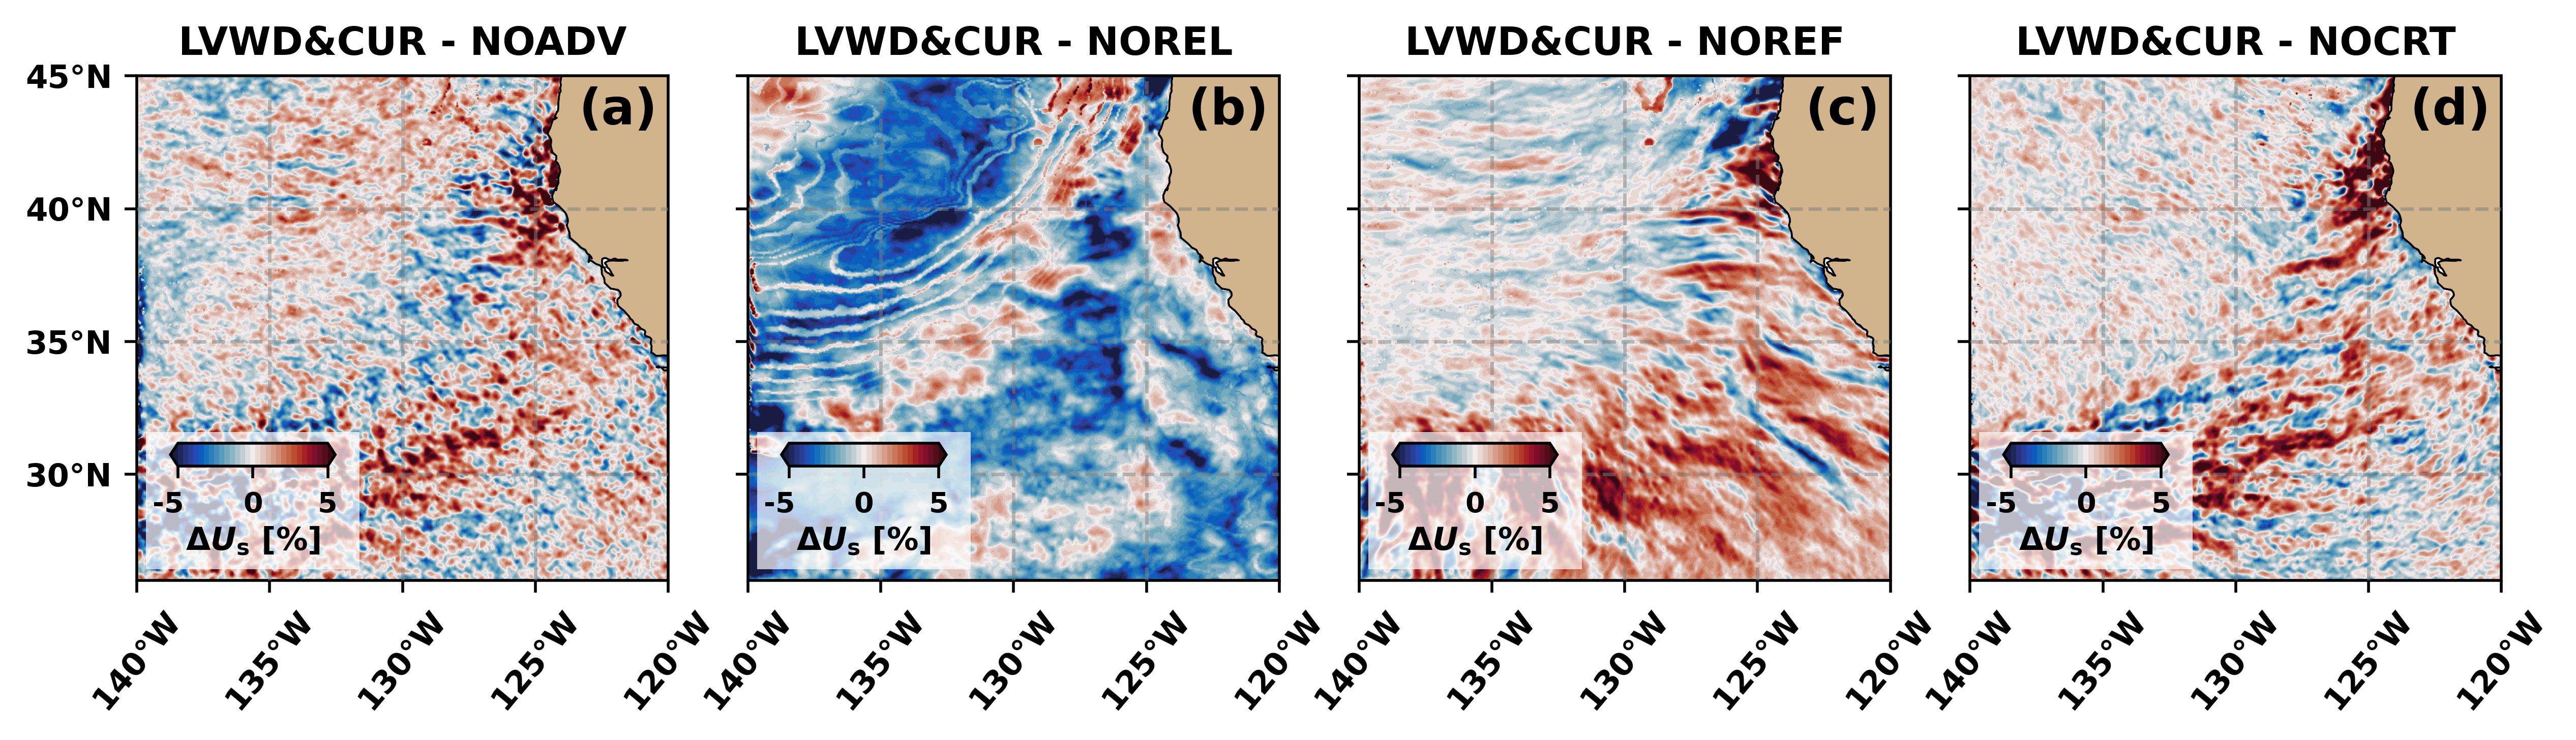

In [47]:
fig, axes = make_four_panel_money_figure(
    four_panel_rows=[
        fig06,
    ],
    ranges=fig06_ranges,
    column_titles=column_titles,
    extent=[-140, -120, 26, 45],
)

plt.show()

In [48]:
fig.savefig(
    '../figures/fig06.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.1,
)